In [1]:
!pip install yfinance

In [2]:
import yfinance as yf

# Download Apple stock data
data = yf.download('AAPL', start='2015-01-01', end='2024-01-01')

# Save dataset
data.to_csv('AAPL_stock_data.csv')

print("Dataset Downloaded Successfully")

# Show first 5 rows
print(data.head())

/tmp/ipykernel_1663/3524372498.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Dataset Downloaded Successfully
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192606  24.659508  23.754470  24.648443  212818400
2015-01-05  23.511053  24.042127  23.325178  23.962466  257142000
2015-01-06  23.513269  23.772167  23.152581  23.575228  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759087  24.816620  24.053201  24.170481  237458000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
data = pd.read_csv("AAPL_stock_data.csv")

# The first two rows are metadata, drop them.
# The actual data starts from index 2.
data = data.iloc[2:].copy()

# The first column, which was 'Price', now contains the dates. Rename it.
data.rename(columns={'Price': 'Date'}, inplace=True)

# Convert the 'Date' column to datetime objects and set it as the index.
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Convert the stock data columns to numeric, coercing any errors to NaN.
# Then drop any rows that might have become all NaN due to conversion issues.
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in numeric_cols:
    # Ensure the column exists before attempting conversion
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop any rows with NaN in the 'Close' column after conversion,
# as these would typically be from the problematic metadata entries.
data.dropna(subset=['Close'], inplace=True)

print(data.head())

                Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192606  24.659508  23.754470  24.648443  212818400
2015-01-05  23.511053  24.042127  23.325178  23.962466  257142000
2015-01-06  23.513269  23.772167  23.152581  23.575228  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759087  24.816620  24.053201  24.170481  237458000


In [5]:
print(data.info())

print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2266 non-null   object
 1   Close   2265 non-null   object
 2   High    2265 non-null   object
 3   Low     2265 non-null   object
 4   Open    2265 non-null   object
 5   Volume  2265 non-null   object
dtypes: object(6)
memory usage: 106.3+ KB
None
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


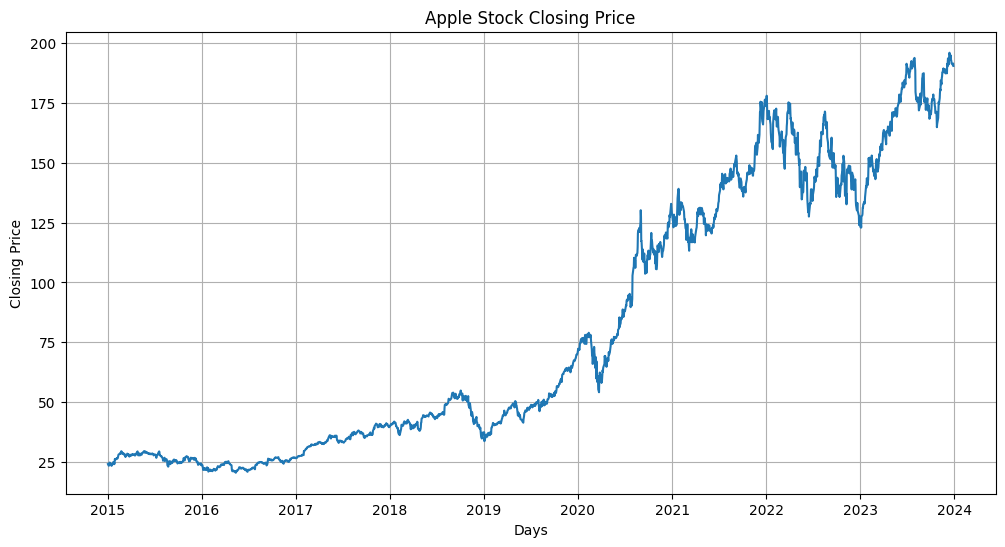

In [8]:
plt.figure(figsize=(12,6))

plt.plot(data['Close'])

plt.title("Apple Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

In [9]:
X = data[['Open', 'High', 'Low', 'Volume']]

y = data['Close']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1811, 4)
Testing Data: (453, 4)


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[167.10835183  77.26787894  22.23726457  24.34167769  27.58188078
 117.02399015  44.38097068 143.44739795  28.43240074 159.63709266]


In [13]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 0.3650212042904536
R2 Score: 0.9998873499604825


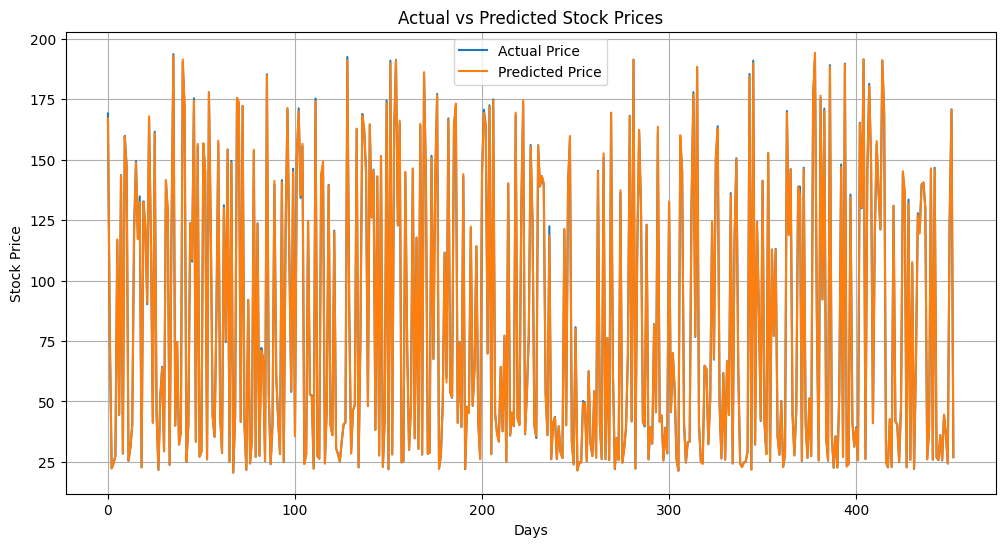

In [14]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price')

plt.plot(y_pred, label='Predicted Price')

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.legend()

plt.grid(True)

plt.show()

In [15]:
sample_data = np.array([[180, 185, 178, 50000000]])

predicted_price = model.predict(sample_data)

print("Predicted Closing Price:")

print(predicted_price)

Predicted Closing Price:
[182.55889677]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
import joblib

joblib.dump(model, 'stock_price_prediction_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully
